Assiagnment Number 1

Part 1: 

In [2]:
pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 23.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


I will be using these libraries to support numerical computations, environment simulation, and result visualization.
Also, emplemented a custom multi-armed bandit environment following the Gymnasium API structure, with 10 arms and Gaussian reward distributions.

In [3]:
# custom environment, Banditenv

import numpy as np
import gymnasium as gym
from gymnasium import spaces

class BanditEnv(gym.Env):
    def __init__(self, k=10):
        super().__init__()
        self.k = k
        self.action_space = spaces.Discrete(k)
        self.observation_space = spaces.Discrete(1)
        self.q_true = None
        self.optimal_action = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.q_true = np.random.normal(0, 1, self.k)
        self.optimal_action = np.argmax(self.q_true)
        observation = 0
        info = {}
        return observation, info

    def step(self, action):
        reward = np.random.normal(self.q_true[action], 1.0)
        observation = 0
        terminated = False
        truncated = False
        info = {"optimal_action": self.optimal_action}
        return observation, reward, terminated, truncated, info

The Epsilin greedy agent is used here to balance exploration and exploitation by selecting random actions with probability and greedy actions otherwise.

In [4]:
# Epsilon greedy agent


class EpsilonGreedyAgent:
    def __init__(self, k=10, epsilon=0.1):
        self.k = k
        self.epsilon = epsilon
        self.reset()

    def reset(self):
        self.q_estimates = np.zeros(self.k)
        self.action_counts = np.zeros(self.k)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)
        return np.argmax(self.q_estimates)

    def update(self, action, reward):
        self.action_counts[action] += 1
        alpha = 1.0 / self.action_counts[action]
        self.q_estimates[action] += alpha * (reward - self.q_estimates[action])

used The UCB agent to explore actions based on uncertainty, using an upper confidence bound to guide action selection.

In [6]:
# UCB agent

class UCBAgent:
    def __init__(self, k=10, c=2.0):
        self.k = k
        self.c = c
        self.reset()

    def reset(self):
        self.q_estimates = np.zeros(self.k)
        self.action_counts = np.zeros(self.k)
        self.t = 0

    def select_action(self):
        self.t += 1

        for action in range(self.k):
            if self.action_counts[action] == 0:
                return action

        ucb_values = self.q_estimates + self.c * np.sqrt(
            np.log(self.t) / self.action_counts
        )
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.action_counts[action] += 1
        alpha = 1.0 / self.action_counts[action]
        self.q_estimates[action] += alpha * (reward - self.q_estimates[action])

I defined a simulation function to evaluate agent performance over multiple runs and time steps while tracking rewards and optimal actions.

In [7]:
# run experiment 

def run_experiment(agent_class, param_name, param_value, runs=1000, steps=2000, k=10):
    rewards = np.zeros((runs, steps))
    optimal_actions = np.zeros((runs, steps))

    for run in range(runs):
        env = BanditEnv(k=k)
        env.reset()

        if param_name == "epsilon":
            agent = agent_class(k=k, epsilon=param_value)
        elif param_name == "c":
            agent = agent_class(k=k, c=param_value)

        for step in range(steps):
            action = agent.select_action()
            _, reward, _, _, info = env.step(action)
            agent.update(action, reward)

            rewards[run, step] = reward
            optimal_actions[run, step] = 1 if action == info["optimal_action"] else 0

    avg_rewards = rewards.mean(axis=0)
    optimal_action_pct = optimal_actions.mean(axis=0) * 100

    return avg_rewards, optimal_action_pct

In [8]:
# Choosing multiple parameter settings

epsilons = [0.01, 0.1, 0.2]
ucb_cs = [0.5, 1.0, 2.0]
results = {}

In [9]:
for eps in epsilons:
    avg_r, opt_pct = run_experiment(EpsilonGreedyAgent, "epsilon", eps)
    results[f"epsilon={eps}"] = (avg_r, opt_pct)

for c in ucb_cs:
    avg_r, opt_pct = run_experiment(UCBAgent, "c", c)
    results[f"ucb_c={c}"] = (avg_r, opt_pct)

The results are visualized using plots to compare average rewards and optimal action percentages across different parameter settings.

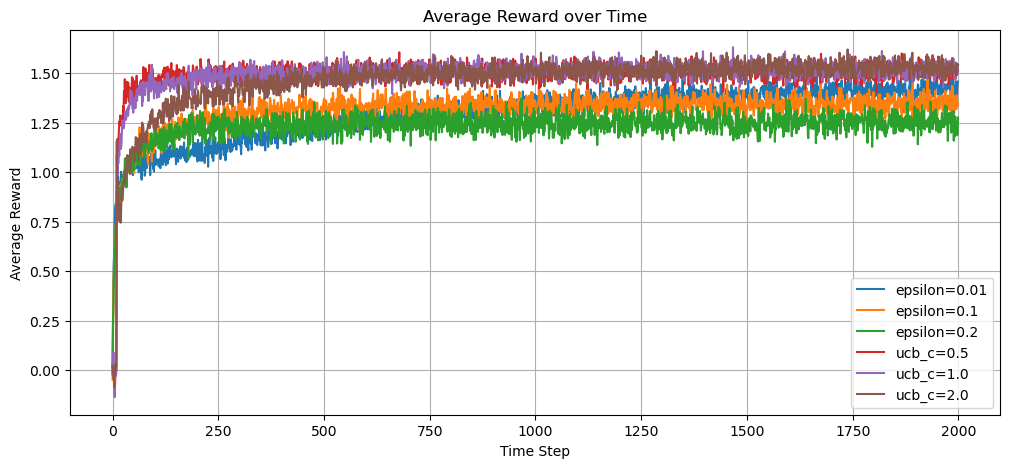

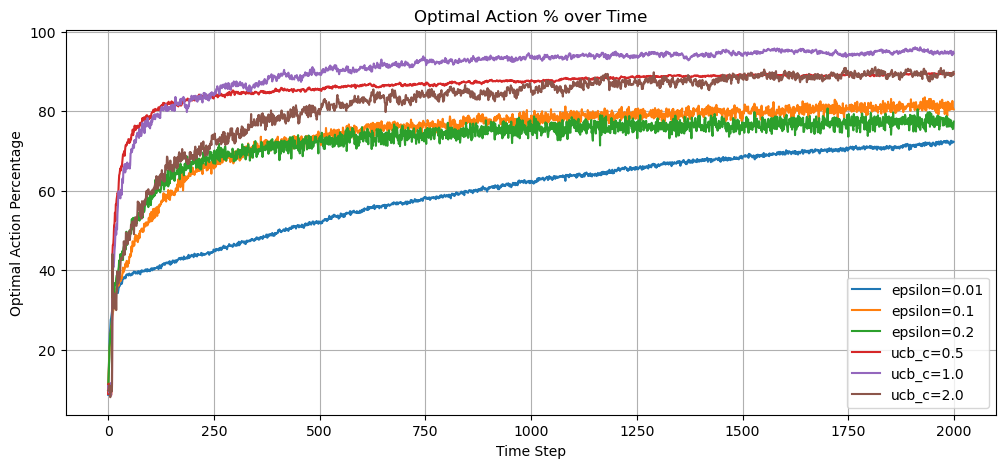

In [10]:
# Plotting the results

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for label, (avg_r, _) in results.items():
    plt.plot(avg_r, label=label)
plt.xlabel("Time Step")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
for label, (_, opt_pct) in results.items():
    plt.plot(opt_pct, label=label)
plt.xlabel("Time Step")
plt.ylabel("Optimal Action Percentage")
plt.title("Optimal Action % over Time")
plt.legend()
plt.grid(True)
plt.show()

the experimental results demonstrate the implications of exploration techniques on learning efficacy. Both ε-greedy and UCB get stronger progressively, but UCB always performs better than ε-greedy when it comes to deciding on the best action and achieving the most rewards. the reason why is because ε-greedy relies on uniform random exploration, and that doesn't give more importance to actions that are unclear. On the contrary, UCB has an uncertainty-based bonus that systematically stimulates investigation of actions that have been less sampled.


Among ε-greedy configurations, smaller ε values (ε = 0.01) lead to higher long-term rewards due to increased exploitation, while larger ε values maintain more exploration at the cost of performance. For UCB, moderate confidence levels (c = 1.0) provide the best balance, while too small or too large values reduce efficiency.


Part 2: 

The structure of standard Gymnasium environments is explored by inspecting their observation and action spaces.

In [11]:
# inspect environment

def inspect_environment(env_name):
    env = gym.make(env_name)
    print(f"\nEnvironment: {env_name}")
    print("Observation space:", env.observation_space)
    print("Action space:", env.action_space)

    if isinstance(env.observation_space, gym.spaces.Discrete):
        print("Observation space type: Discrete")
        print("Number of states:", env.observation_space.n)
    elif isinstance(env.observation_space, gym.spaces.Box):
        print("Observation space type: Continuous (Box)")
        print("Shape:", env.observation_space.shape)
        print("Low bounds:", env.observation_space.low)
        print("High bounds:", env.observation_space.high)

    if isinstance(env.action_space, gym.spaces.Discrete):
        print("Action space type: Discrete")
        print("Number of actions:", env.action_space.n)
    elif isinstance(env.action_space, gym.spaces.Box):
        print("Action space type: Continuous (Box)")
        print("Shape:", env.action_space.shape)
        print("Low bounds:", env.action_space.low)
        print("High bounds:", env.action_space.high)

    env.close()

In [12]:
inspect_environment("FrozenLake-v1")
inspect_environment("Taxi-v3")


Environment: FrozenLake-v1
Observation space: Discrete(16)
Action space: Discrete(4)
Observation space type: Discrete
Number of states: 16
Action space type: Discrete
Number of actions: 4

Environment: Taxi-v3
Observation space: Discrete(500)
Action space: Discrete(6)
Observation space type: Discrete
Number of states: 500
Action space type: Discrete
Number of actions: 6


this means: for Frozen lake-V1, we have
16 possible states
4 possible actions

for Taxi-V3: 
500 possible states
6 possible actions

So both of these are discrete state and discrete action MDPs.

Implemented a random policy agent to be a baseline by selecting actions uniformly at random.

In [13]:
# Creatign a random policy agent 

class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def select_action(self, observation):
        return self.action_space.sample()

The performance of the random agent is evaluated across multiple episodes to see its effectiveness in each environment.

In [14]:
# Evaluate the random agent

def evaluate_random_agent(env_name, episodes=500):
    env = gym.make(env_name)
    agent = RandomAgent(env.action_space)

    episode_rewards = []

    for _ in range(episodes):
        observation, info = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.select_action(observation)
            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        episode_rewards.append(total_reward)

    env.close()
    return np.mean(episode_rewards), np.std(episode_rewards)

Summarizing the key properties of each environment, including state and action space characteristics.

In [15]:
# environment inspection output

for env_name in ["FrozenLake-v1", "Taxi-v3"]:
    avg_reward, std_reward = evaluate_random_agent(env_name)
    print(f"{env_name}: Average Reward = {avg_reward:.2f}, Std = {std_reward:.2f}")

FrozenLake-v1: Average Reward = 0.01, Std = 0.10
Taxi-v3: Average Reward = -770.79, Std = 110.95


random-policy results: 

As may be expected, the random agent does poorly in both settings. The average reward in FrozenLake-v1 is almost zero, suggesting that the agent hardly achieves the objective because of holes and random movement. The low standard deviation indicates that there is only infrequent success and that the majority of events end in failure.


The average reward in Taxi-v3 is very negative, indicating that the agent earns penalties over a number of steps without effectively finishing the task. Depending on how long the agent takes and how many wrong acts it makes, the high standard deviation shows that performance fluctuates considerably between episodes.

MDP tuple mapping to Gymnasium: 


Gymnasium's API is easily mapped to the Markov Decision Process (MDP) tuple (S, A, R, P, γ). The observation that env.reset() and env.step() return represents the state (S). The valid activities that the agent can perform are specified by env.action_space, which defines the action space (A). The output of env.step(action) includes the reward (R). The environment determines how the state changes following each action by handling the transition probabilities (P) internally. Lastly, the agent selects the discount factor (γ) while executing a learning process; it is not a component of the environment though.